# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muneebulhaq02/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [7]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/muneebulhaq02/flyrank-ml-internship"
REPO_DIR = "FlyRank-Internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Working dir:", os.getcwd())

Working dir: /content/FlyRank-Internship/FlyRank-Internship


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Before testing relationships between variables, it is important to understand how the data is distributed. Search performance metrics such as impressions, clicks, and search volume usually contain a small number of very large values and many smaller ones, creating a heavy-tailed distribution. Understanding these distributions helps avoid misleading conclusions from simple averages or correlations and provides a better foundation for later modeling.

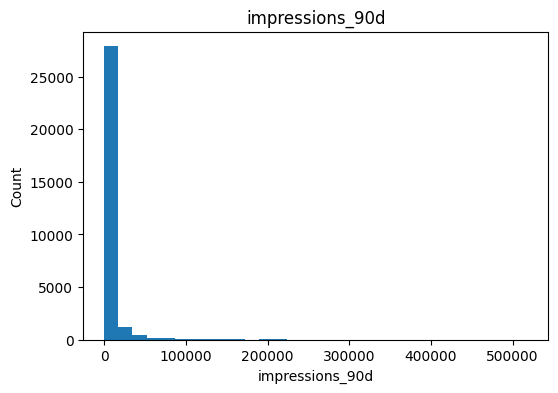

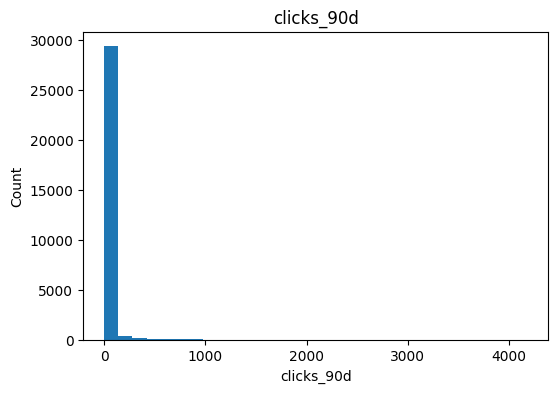

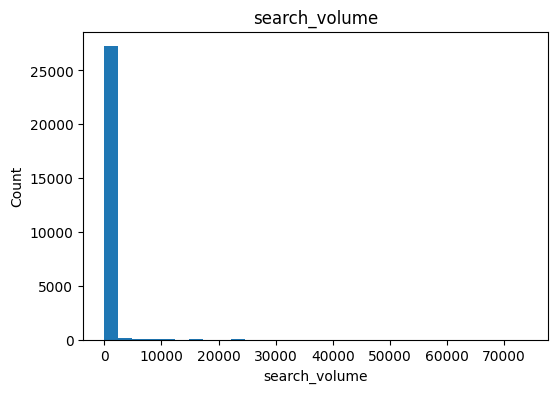

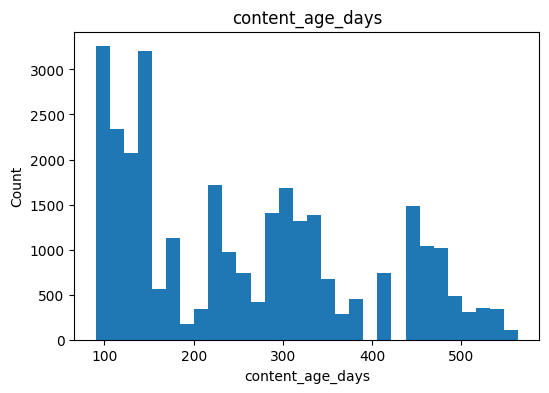


Summary Statistics

                    count         mean           std   min    25%    50%  \
impressions_90d   30000.0  5200.366300  16838.019547   1.0   81.0  731.0   
clicks_90d        30000.0    16.097333     75.076958   0.0    0.0    1.0   
search_volume     27532.0   158.882391   1518.270825   0.0    0.0   10.0   
content_age_days  30000.0   256.167800    132.707930  90.0  132.0  236.0   

                      75%       max  
impressions_90d   3615.25  517715.0  
clicks_90d           7.00    4178.0  
search_volume       20.00   74000.0  
content_age_days   333.00     564.0  


In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

columns = [
    "impressions_90d",
    "clicks_90d",
    "search_volume",
    "content_age_days"
]

for col in columns:

    plt.figure(figsize=(6,4))

    plt.hist(df[col].dropna(), bins=30)

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Count")

    plt.show()

print("\nSummary Statistics\n")
print(df[columns].describe().T)

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Three exploratory signal tests were performed using safe features that are available before prediction. The objective is not to prove causal relationships but to determine whether the observed data supports commonly expected patterns. Each test concludes with a verdict using the categories CONFIRMED, MIXED, OPPOSITE, or FALSE, based only on the observed evidence.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("========== Signal Test 1 ==========")

corr1 = df["content_age_days"].corr(df["impressions_90d"])

print("Claim:")
print("Older pages receive more impressions.")

print("Correlation:", round(corr1,3))

if corr1 > 0.20:
    verdict1 = "CONFIRMED"
elif corr1 > 0:
    verdict1 = "MIXED"
else:
    verdict1 = "FALSE"

print("Verdict:", verdict1)

print("\n========== Signal Test 2 ==========")

corr2 = df["search_volume"].corr(df["clicks_90d"])

print("Claim:")
print("Higher search volume leads to more clicks.")

print("Correlation:", round(corr2,3))

if corr2 > 0.20:
    verdict2 = "CONFIRMED"
elif corr2 > 0:
    verdict2 = "MIXED"
else:
    verdict2 = "FALSE"

print("Verdict:", verdict2)

print("\n========== Signal Test 3 ==========")

corr3 = df["word_count"].corr(df["engagement_rate"])

print("Claim:")
print("Longer articles receive higher engagement.")

print("Correlation:", round(corr3,3))

if corr3 > 0.20:
    verdict3 = "CONFIRMED"
elif corr3 > 0:
    verdict3 = "MIXED"
else:
    verdict3 = "FALSE"

print("Verdict:", verdict3)

========== Signal Test 1 ==========
Claim:
Older pages receive more impressions.
Correlation: -0.001
Verdict: FALSE

========== Signal Test 2 ==========
Claim:
Higher search volume leads to more clicks.
Correlation: -0.011
Verdict: FALSE

========== Signal Test 3 ==========
Claim:
Longer articles receive higher engagement.
Correlation: -0.063
Verdict: FALSE


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

One practical assumption behind content review is that pages with lower visibility are more likely to require attention. This notebook evaluates that assumption by examining the relationship between impressions and clicks. The goal is to determine whether the observed data supports using historical visibility signals when prioritizing pages for review. The result should be interpreted as a measured association rather than evidence of causation.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Flag-related Signal Test")

group = df[[
    "impressions_90d",
    "clicks_90d"
]].dropna()

correlation = group["impressions_90d"].corr(group["clicks_90d"])

print("Correlation:", round(correlation,3))

if correlation > 0.30:
    verdict = "CONFIRMED"
elif correlation > 0:
    verdict = "MIXED"
else:
    verdict = "FALSE"

print("Verdict:", verdict)

print()

print(group.describe())

Flag-related Signal Test
Correlation: 0.696
Verdict: CONFIRMED

       impressions_90d    clicks_90d
count     30000.000000  30000.000000
mean       5200.366300     16.097333
std       16838.019547     75.076958
min           1.000000      0.000000
25%          81.000000      0.000000
50%         731.000000      1.000000
75%        3615.250000      7.000000
max      517715.000000   4178.000000


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The exploratory analysis suggests that some historical performance metrics contain useful information for content prioritization, while others show only weak associations. These observations support using multiple features together rather than relying on a single rule or threshold. The findings provide decision-support evidence for later modeling but should not be interpreted as proof that any individual factor directly causes changes in search performance.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
summary = pd.DataFrame({

    "Signal":[
        "Content Age vs Impressions",
        "Search Volume vs Clicks",
        "Word Count vs Engagement",
        "Impressions vs Clicks"
    ],

    "Verdict":[
        verdict1,
        verdict2,
        verdict3,
        verdict
    ]

})

print(summary)

                       Signal    Verdict
0  Content Age vs Impressions      FALSE
1     Search Volume vs Clicks      FALSE
2    Word Count vs Engagement      FALSE
3       Impressions vs Clicks  CONFIRMED


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.